<a href="https://colab.research.google.com/github/maxGrigorenko/DL_HSE/blob/hw_5/Depth_Anything_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Григоренко Максим. Построение карт глубины при помощи Depth-Anything-3

In [1]:
# Клонируем репозиторий
!git clone https://github.com/ByteDance-Seed/Depth-Anything-3.git

# Переходим в папку проекта
%cd Depth-Anything-3

# Устанавливаем базовые зависимости (xformers ускоряет работу трансформеров)
!pip install xformers
!pip install -e .

fatal: destination path 'Depth-Anything-3' already exists and is not an empty directory.
/content/Depth-Anything-3
Obtaining file:///content/Depth-Anything-3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for depth-anything-3 (pyproject.toml) ... done
  Created wheel for depth-anything-3: filename=depth_anything_3-0.0.0-py3-none-any.whl size=12473 sha256=40936c8e712ad5c44641309aa507129cc96d5818a96ada23e032bad1d89fe088
  Stored in directory: /tmp/pip-ephem-wheel-cache-oxx2_9bm/wheels/a4/a6/b9/c3ad67065497f9ae7738b6d42a8001fbb063ae56096d7b0043
Successfully built depth-anything-3
  Attempting uninstall: depth-anything-3
    Found existing installation: depth-anything-3 0.0.0
    Uninstalling depth-anything-3-0.0.0:
      Successfully uninstalled depth-anything-3-0.0.0


In [3]:
import os
import torch
import torchvision
import torchvision.transforms.functional as F
from tqdm import tqdm
import random
from depth_anything_3.api import DepthAnything3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}")

model = DepthAnything3.from_pretrained("depth-anything/DA3MONO-LARGE")
model = model.to(device).eval()

# Создаем чистые директории
os.makedirs('/content/processed/train', exist_ok=True)
os.makedirs('/content/processed/test', exist_ok=True)

# Очищаем папки на случай, если среда не была перезапущена
!rm -rf /content/processed/train/* /content/processed/test/*

# Загружаем Caltech101
caltech = torchvision.datasets.Caltech101(root='./data', download=True)

# Фильтруем классы с хорошей геометрией
target_names = ['chair', 'camera', 'laptop', 'Motorbikes']
target_indices = [caltech.categories.index(name) for name in target_names]

filtered_data = []
for i in range(len(caltech)):
    img, label = caltech[i]
    if label in target_indices:
        new_label = target_indices.index(label)
        filtered_data.append((img.convert('RGB'), new_label))

print(f"Найдено {len(filtered_data)} изображений целевых классов.")

# Бьем на train (80%) и test (20%)
random.seed(42)
random.shuffle(filtered_data)
split_idx = int(len(filtered_data) * 0.8)
train_data = filtered_data[:split_idx]
test_data = filtered_data[split_idx:]

Используем устройство: cuda
[INFO ] using MLP layer as FFN
Найдено 991 изображений целевых классов.


In [4]:
def process_and_save(data_list, save_dir):
    for i, (img, label) in enumerate(tqdm(data_list, desc=f"Обработка {save_dir}")):
        img_resized = img.resize((224, 224))

        img_path = f"/content/temp_img_{i}.jpg"
        img_resized.save(img_path)

        with torch.no_grad():
            pred = model.inference([img_path])

        depth = torch.from_numpy(pred.depth[0]).unsqueeze(0)
        rgb = F.to_tensor(img_resized)

        torch.save({'rgb': rgb, 'depth': depth, 'label': label}, f"{save_dir}/sample_{i}.pt")
        if os.path.exists(img_path):
            os.remove(img_path)

process_and_save(train_data, '/content/processed/train')
process_and_save(test_data, '/content/processed/test')

Обработка /content/processed/train:   0%|          | 0/792 [00:00<?, ?it/s]

[INFO ] Processed Images Done taking 0.24858760833740234 seconds. Shape:  torch.Size([1, 3, 504, 504])


Обработка /content/processed/train:   0%|          | 1/792 [00:01<21:12,  1.61s/it]

[INFO ] Model Forward Pass Done. Time: 1.3386356830596924 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0014081001281738281 seconds
[INFO ] Processed Images Done taking 0.01357126235961914 seconds. Shape:  torch.Size([1, 3, 504, 504])


Обработка /content/processed/train:   0%|          | 2/792 [00:02<12:41,  1.04it/s]

...

[INFO ] Model Forward Pass Done. Time: 0.5580995082855225 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0013856887817382812 seconds
[INFO ] Processed Images Done taking 0.012636661529541016 seconds. Shape:  torch.Size([1, 3, 504, 504])


Обработка /content/processed/test:  99%|█████████▉| 198/199 [01:58<00:00,  1.70it/s]

[INFO ] Model Forward Pass Done. Time: 0.5599713325500488 seconds
[INFO ] Conversion to Prediction Done. Time: 0.001421213150024414 seconds
[INFO ] Processed Images Done taking 0.014482498168945312 seconds. Shape:  torch.Size([1, 3, 504, 504])


Обработка /content/processed/test: 100%|██████████| 199/199 [01:58<00:00,  1.67it/s]

[INFO ] Model Forward Pass Done. Time: 0.557727575302124 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0013494491577148438 seconds


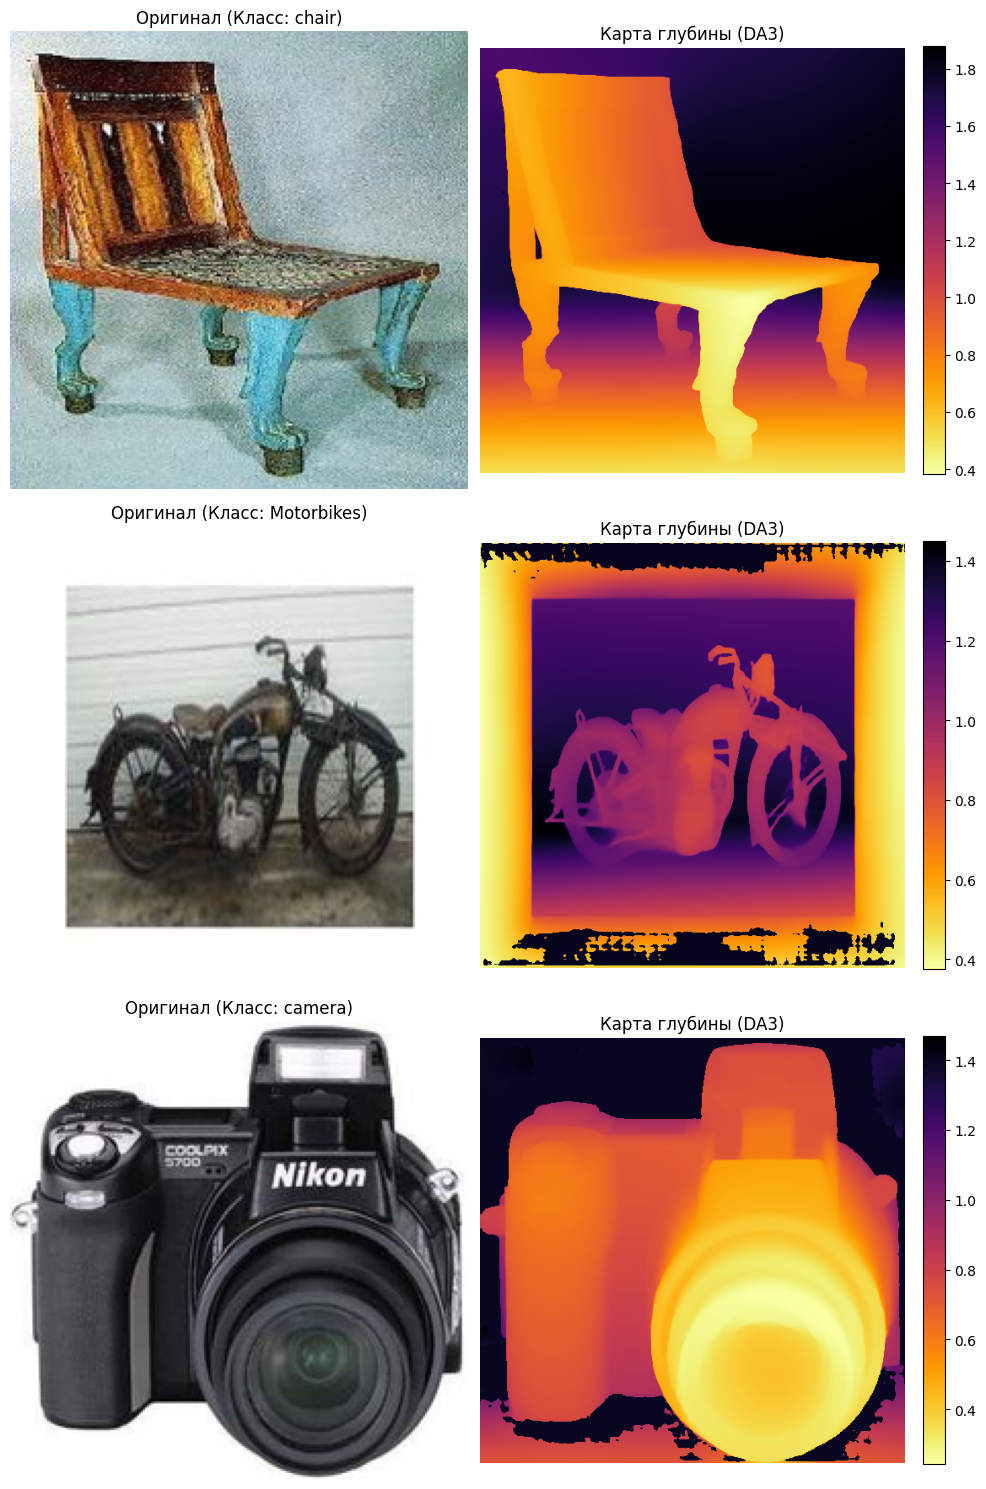

In [9]:
import matplotlib.pyplot as plt
import torch
import glob
import random

# Берем список всех сохраненных файлов и выбираем 3 случайных
train_files = glob.glob('/content/processed/train/*.pt')
sample_files = random.sample(train_files, 3)

fig, axes = plt.subplots(3, 2, figsize=(10, 15))

for i, file_path in enumerate(sample_files):
    # Читаем данные из нашего .pt кэша
    data = torch.load(file_path, weights_only=True)

    # Переводим RGB из формата PyTorch [3, 224, 224] в формат для отрисовки [224, 224, 3]
    rgb = data['rgb'].permute(1, 2, 0).numpy()

    # Убираем лишнее измерение из глубины: [1, H, W] -> [H, W]
    depth = data['depth'].squeeze(0).numpy()
    label = data['label']

    # Отрисовка оригинала
    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"Оригинал (Класс: {target_names[label]})")
    axes[i, 0].axis('off')

    # Отрисовка карты глубины (используем стиль inferno_r: светлое - близко)
    im = axes[i, 1].imshow(depth, cmap='inferno_r')
    axes[i, 1].set_title("Карта глубины (DA3)")
    axes[i, 1].axis('off')
    fig.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [10]:
from torch.utils.data import Dataset, DataLoader

class RGBDepthDataset(Dataset):
    def __init__(self, data_dir, is_train=False):
        self.files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.pt')]
        self.is_train = is_train

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = torch.load(self.files[idx], weights_only=True)
        rgb = data['rgb']
        depth = data['depth']
        label = data['label']

        # Подгоняем размер карты глубины под RGB
        if depth.shape[1:] != (224, 224):
            depth = F.resize(depth, [224, 224], interpolation=F.InterpolationMode.BILINEAR)

        rgbd = torch.cat([rgb, depth], dim=0)

        # Синхронное отзеркаливание
        if self.is_train and random.random() > 0.5:
            rgbd = F.hflip(rgbd)

        return rgbd[:3, :, :], rgbd, label

train_dataset = RGBDepthDataset('/content/processed/train', is_train=True)
test_dataset = RGBDepthDataset('/content/processed/test', is_train=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

=== Обучение Baseline (только RGB) ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


Epoch 01 | Loss: 0.418 | Accuracy: 0.995
Epoch 02 | Loss: 0.031 | Accuracy: 0.995
Epoch 03 | Loss: 0.028 | Accuracy: 1.000
Epoch 04 | Loss: 0.007 | Accuracy: 0.995
Epoch 05 | Loss: 0.004 | Accuracy: 0.995
Epoch 06 | Loss: 0.008 | Accuracy: 0.990
Epoch 07 | Loss: 0.006 | Accuracy: 0.985
Epoch 08 | Loss: 0.003 | Accuracy: 0.990
Epoch 09 | Loss: 0.004 | Accuracy: 0.990
Epoch 10 | Loss: 0.002 | Accuracy: 0.990

=== Обучение Experiment (RGB + Depth) ===
Epoch 01 | Loss: 0.340 | Accuracy: 1.000
Epoch 02 | Loss: 0.031 | Accuracy: 0.990
Epoch 03 | Loss: 0.008 | Accuracy: 1.000
Epoch 04 | Loss: 0.008 | Accuracy: 0.990
Epoch 05 | Loss: 0.005 | Accuracy: 1.000
Epoch 06 | Loss: 0.004 | Accuracy: 1.000
Epoch 07 | Loss: 0.003 | Accuracy: 1.000
Epoch 08 | Loss: 0.008 | Accuracy: 1.000
Epoch 09 | Loss: 0.028 | Accuracy: 0.995
Epoch 10 | Loss: 0.032 | Accuracy: 1.000


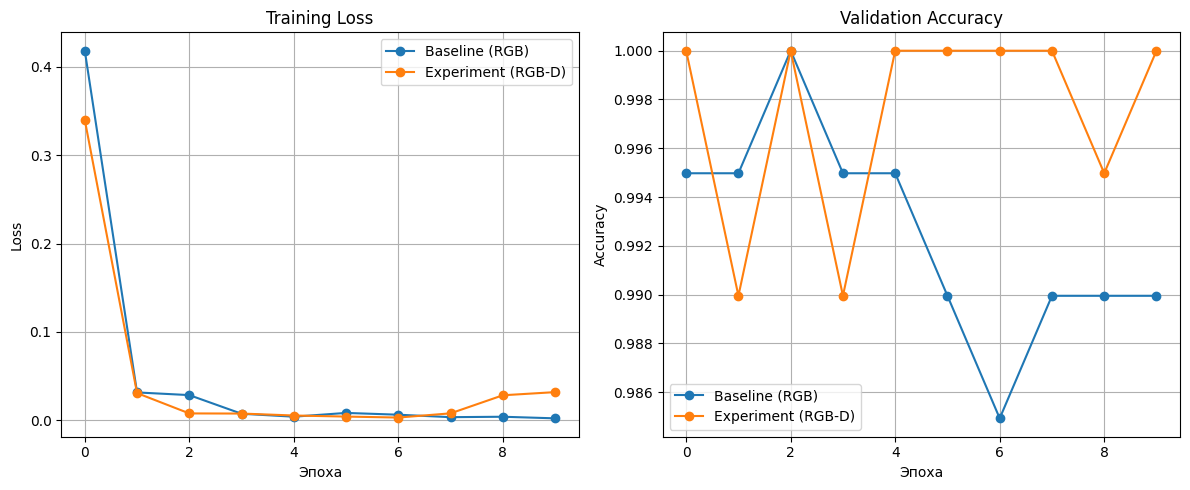

In [11]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Архитектуры ---
def get_resnet_baseline():
    net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    net.fc = nn.Linear(net.fc.in_features, 4)
    return net.to(device)

def get_resnet_experiment():
    net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    old_conv = net.conv1

    new_conv = nn.Conv2d(4, old_conv.out_channels,
                          kernel_size=old_conv.kernel_size,
                          stride=old_conv.stride,
                          padding=old_conv.padding,
                          bias=False)

    with torch.no_grad():
        new_conv.weight[:, :3, :, :] = old_conv.weight
        new_conv.weight[:, 3:4, :, :] = old_conv.weight.mean(dim=1, keepdim=True)

    net.conv1 = new_conv
    net.fc = nn.Linear(net.fc.in_features, 4)
    return net.to(device)

# --- Цикл обучения ---
def train_and_eval(net, use_depth=False, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=1e-4)
    history = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        net.train()
        total_loss = 0
        for rgb, rgbd, label in train_loader:
            inputs = rgbd.to(device) if use_depth else rgb.to(device)
            label = label.to(device)

            optimizer.zero_grad()
            out = net(inputs)
            loss = criterion(out, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        net.eval()
        correct = 0
        with torch.no_grad():
            for rgb, rgbd, label in test_loader:
                inputs = rgbd.to(device) if use_depth else rgb.to(device)
                out = net(inputs)
                correct += (out.argmax(1) == label.to(device)).sum().item()

        history['loss'].append(total_loss / len(train_loader))
        history['acc'].append(correct / len(test_dataset))
        print(f"Epoch {epoch+1:02d} | Loss: {history['loss'][-1]:.3f} | Accuracy: {history['acc'][-1]:.3f}")

    return history

# --- Запуск ---
print("=== Обучение Baseline (только RGB) ===")
baseline_net = get_resnet_baseline()
hist_base = train_and_eval(baseline_net, use_depth=False)

print("\n=== Обучение Experiment (RGB + Depth) ===")
exp_net = get_resnet_experiment()
hist_exp = train_and_eval(exp_net, use_depth=True)

# --- Графики ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_base['loss'], label='Baseline (RGB)', marker='o')
plt.plot(hist_exp['loss'], label='Experiment (RGB-D)', marker='o')
plt.title('Training Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_base['acc'], label='Baseline (RGB)', marker='o')
plt.plot(hist_exp['acc'], label='Experiment (RGB-D)', marker='o')
plt.title('Validation Accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Обе модели справились

=== Обучение Baseline (RGB + шум) ===
Epoch 01 | Loss: 0.729 | Accuracy: 0.206
Epoch 02 | Loss: 0.235 | Accuracy: 0.337
Epoch 03 | Loss: 0.122 | Accuracy: 0.955
Epoch 04 | Loss: 0.105 | Accuracy: 0.975
Epoch 05 | Loss: 0.063 | Accuracy: 0.965
Epoch 06 | Loss: 0.081 | Accuracy: 0.965
Epoch 07 | Loss: 0.043 | Accuracy: 0.980
Epoch 08 | Loss: 0.055 | Accuracy: 0.990
Epoch 09 | Loss: 0.045 | Accuracy: 0.970
Epoch 10 | Loss: 0.037 | Accuracy: 0.985

=== Обучение Experiment (RGB с шумом + Чистая Глубина) ===
Epoch 01 | Loss: 0.567 | Accuracy: 0.920
Epoch 02 | Loss: 0.042 | Accuracy: 0.995
Epoch 03 | Loss: 0.041 | Accuracy: 1.000
Epoch 04 | Loss: 0.025 | Accuracy: 1.000
Epoch 05 | Loss: 0.017 | Accuracy: 1.000
Epoch 06 | Loss: 0.019 | Accuracy: 1.000
Epoch 07 | Loss: 0.008 | Accuracy: 1.000
Epoch 08 | Loss: 0.010 | Accuracy: 1.000
Epoch 09 | Loss: 0.005 | Accuracy: 1.000
Epoch 10 | Loss: 0.005 | Accuracy: 1.000


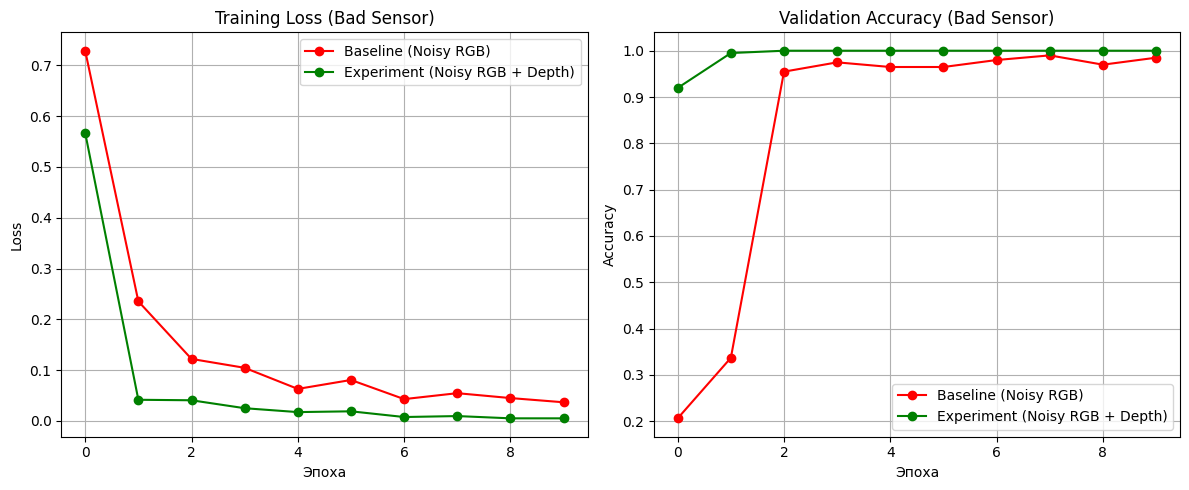

In [12]:
# Эксперимент в сложных условиях (Сломанный сенсор / Темнота) ===

# Функция для имитации поломки камеры / ночной съемки
def simulate_bad_sensor(rgb_tensor):
    # Убиваем яркость до 15% от оригинала
    dark_tensor = rgb_tensor * 0.15
    # Добавляем сильный матричный шум
    noise = torch.randn_like(dark_tensor) * 0.15
    # Ограничиваем значения, чтобы не вылететь за пределы [0, 1]
    return torch.clamp(dark_tensor + noise, 0.0, 1.0)

# --- Обновленный цикл обучения ---
def train_and_eval_bad_sensor(net, use_depth=False, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=1e-4)
    history = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        net.train()
        total_loss = 0
        for rgb, rgbd, label in train_loader:
            label = label.to(device)

            # --- ИСКУССТВЕННАЯ ДЕГРАДАЦИЯ ---
            rgb_bad = simulate_bad_sensor(rgb).to(device)

            if use_depth:
                # Берем сломанный RGB и склеиваем с ИДЕАЛЬНОЙ картой глубины
                depth_clean = rgbd[:, 3:4, :, :].to(device)
                inputs = torch.cat([rgb_bad, depth_clean], dim=1)
            else:
                inputs = rgb_bad
            # --------------------------------

            optimizer.zero_grad()
            out = net(inputs)
            loss = criterion(out, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Валидация
        net.eval()
        correct = 0
        with torch.no_grad():
            for rgb, rgbd, label in test_loader:
                label = label.to(device)

                rgb_bad = simulate_bad_sensor(rgb).to(device)
                if use_depth:
                    depth_clean = rgbd[:, 3:4, :, :].to(device)
                    inputs = torch.cat([rgb_bad, depth_clean], dim=1)
                else:
                    inputs = rgb_bad

                out = net(inputs)
                correct += (out.argmax(1) == label).sum().item()

        history['loss'].append(total_loss / len(train_loader))
        history['acc'].append(correct / len(test_dataset))
        print(f"Epoch {epoch+1:02d} | Loss: {history['loss'][-1]:.3f} | Accuracy: {history['acc'][-1]:.3f}")

    return history

# --- Запуск эксперимента "Сломанный сенсор" ---
print("=== Обучение Baseline (RGB + шум) ===")
# Инициализируем новые модели, чтобы они учились с нуля
bad_baseline_net = get_resnet_baseline()
hist_bad_base = train_and_eval_bad_sensor(bad_baseline_net, use_depth=False)

print("\n=== Обучение Experiment (RGB с шумом + Чистая Глубина) ===")
bad_exp_net = get_resnet_experiment()
hist_bad_exp = train_and_eval_bad_sensor(bad_exp_net, use_depth=True)

# --- Визуализация метрик для плохих условий ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_bad_base['loss'], label='Baseline (Noisy RGB)', marker='o', color='red')
plt.plot(hist_bad_exp['loss'], label='Experiment (Noisy RGB + Depth)', marker='o', color='green')
plt.title('Training Loss (Bad Sensor)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_bad_base['acc'], label='Baseline (Noisy RGB)', marker='o', color='red')
plt.plot(hist_bad_exp['acc'], label='Experiment (Noisy RGB + Depth)', marker='o', color='green')
plt.title('Validation Accuracy (Bad Sensor)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

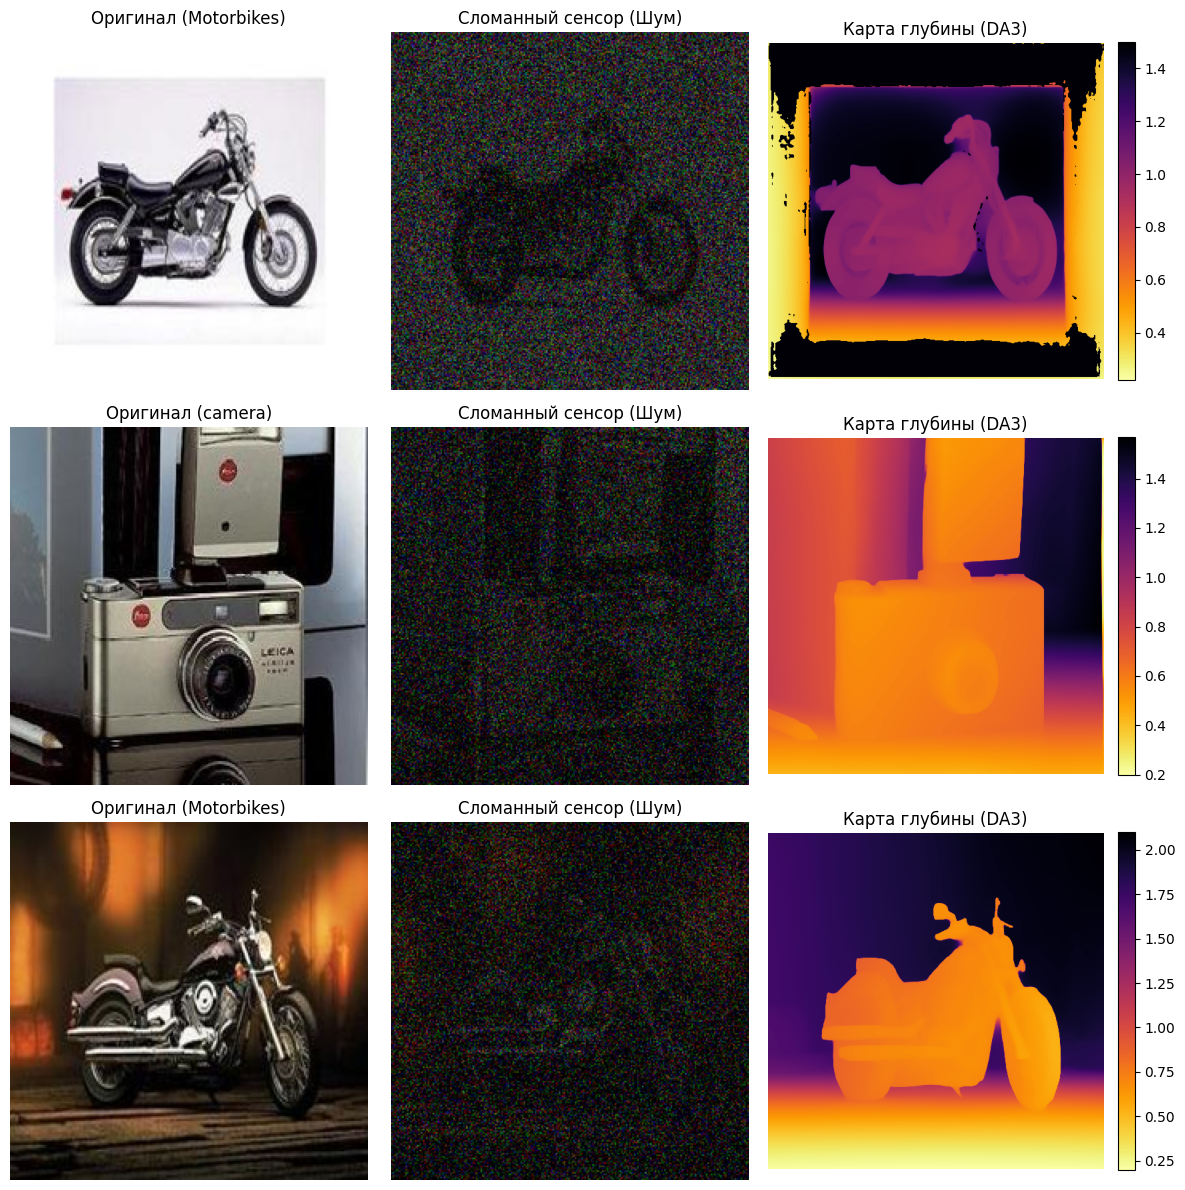

In [17]:
import matplotlib.pyplot as plt
import torch
import glob
import random

# Берем список всех сохраненных файлов и выбираем 3 случайных
train_files = glob.glob('/content/processed/train/*.pt')
sample_files = random.sample(train_files, 3)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
target_names = ['chair', 'camera', 'laptop', 'Motorbikes']

for i, file_path in enumerate(sample_files):
    # Читаем данные из кэша
    data = torch.load(file_path, weights_only=True)
    rgb_tensor = data['rgb']
    depth = data['depth'].squeeze(0).numpy()
    label = data['label']

    # Применяем искусственную деградацию к тензору
    noisy_rgb_tensor = simulate_bad_sensor(rgb_tensor)

    # Конвертируем для matplotlib
    rgb = rgb_tensor.permute(1, 2, 0).numpy()
    noisy_rgb = noisy_rgb_tensor.permute(1, 2, 0).numpy()

    # 1. Оригинальный RGB
    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"Оригинал ({target_names[label]})")
    axes[i, 0].axis('off')

    # 2. Зашумленный RGB (то, что видит Baseline)
    axes[i, 1].imshow(noisy_rgb)
    axes[i, 1].set_title("Сломанный сенсор (Шум)")
    axes[i, 1].axis('off')

    # 3. Карта глубины (то, что спасает Experiment)
    im = axes[i, 2].imshow(depth, cmap='inferno_r')
    axes[i, 2].set_title("Карта глубины (DA3)")
    axes[i, 2].axis('off')
    fig.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Мы видим, что с зашумленными изображениями модель с картами глубины справилась лучше, но эти карты глубины были построены по "чистым" изображениям. Далее протестируем в равных условиях с шумными данными

[INFO ] Processed Images Done taking 0.010438680648803711 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.5907292366027832 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0013403892517089844 seconds
[INFO ] Processed Images Done taking 0.009537696838378906 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.5166764259338379 seconds
[INFO ] Conversion to Prediction Done. Time: 0.001318216323852539 seconds
[INFO ] Processed Images Done taking 0.009048223495483398 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.5156519412994385 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0014128684997558594 seconds


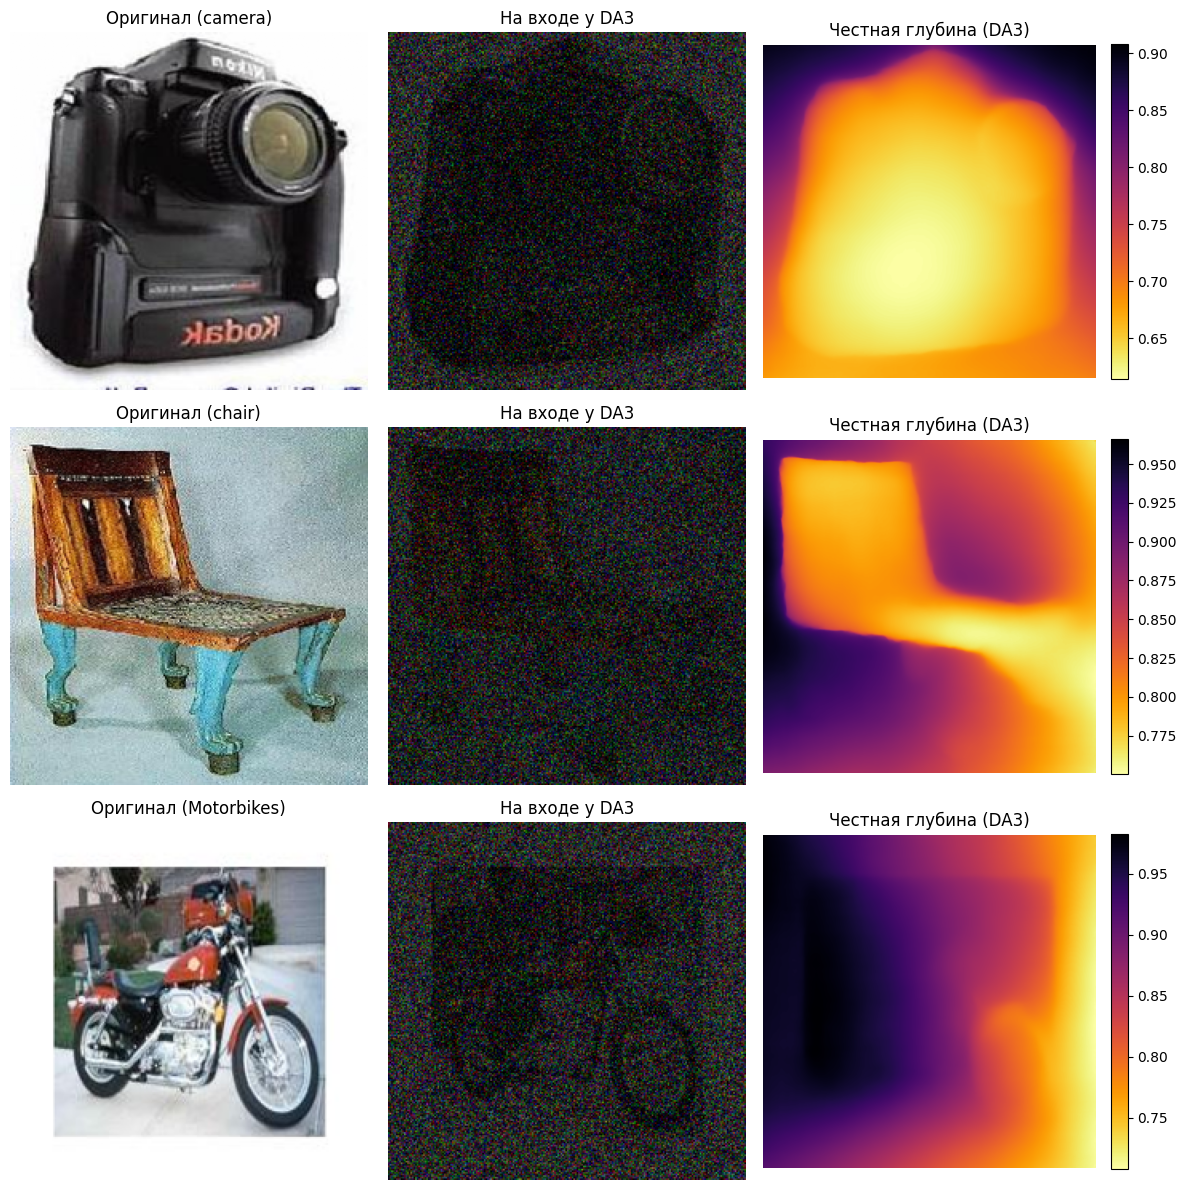

In [19]:
import matplotlib.pyplot as plt
import random
import os
import torch
import torchvision.transforms.functional as F

# Функция деградации
def simulate_bad_sensor(rgb_tensor):
    dark_tensor = rgb_tensor * 0.15
    noise = torch.randn_like(dark_tensor) * 0.15
    return torch.clamp(dark_tensor + noise, 0.0, 1.0)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
# Берем 3 случайные картинки из обучающей выборки (которая в памяти)
sample_data = random.sample(train_data, 3)

for i, (img, label) in enumerate(sample_data):
    img_resized = img.resize((224, 224))

    # 1. Оригинал
    rgb_tensor = F.to_tensor(img_resized)

    # 2. Искусственный шум
    noisy_rgb_tensor = simulate_bad_sensor(rgb_tensor)
    noisy_img_pil = F.to_pil_image(noisy_rgb_tensor)

    # Сохраняем зашумленную версию на диск для API модели
    img_path = f"/content/temp_stress_{i}.jpg"
    noisy_img_pil.save(img_path)

    # 3. ЧЕСТНЫЙ ИНФЕРЕНС DA3 ПО ШУМУ
    with torch.no_grad():
        pred = model.inference([img_path])
    depth = pred.depth[0]
    os.remove(img_path)

    # --- Отрисовка ---
    axes[i, 0].imshow(rgb_tensor.permute(1, 2, 0).numpy())
    axes[i, 0].set_title(f"Оригинал ({target_names[label]})")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(noisy_rgb_tensor.permute(1, 2, 0).numpy())
    axes[i, 1].set_title("На входе у DA3")
    axes[i, 1].axis('off')

    im = axes[i, 2].imshow(depth, cmap='inferno_r')
    axes[i, 2].set_title("Честная глубина (DA3)")
    axes[i, 2].axis('off')
    fig.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Генерируем честный стресс-датасет...


Честный препроцессинг /content/processed/train:   0%|          | 0/792 [00:00<?, ?it/s]

[INFO ] Processed Images Done taking 0.009675741195678711 seconds. Shape:  torch.Size([1, 3, 504, 504])


Честный препроцессинг /content/processed/train:   0%|          | 1/792 [00:00<08:35,  1.53it/s]

[INFO ] Model Forward Pass Done. Time: 0.6265411376953125 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0014166831970214844 seconds
[INFO ] Processed Images Done taking 0.009181022644042969 seconds. Shape:  torch.Size([1, 3, 504, 504])


...

Честный препроцессинг /content/processed/test:  99%|█████████▉| 198/199 [01:59<00:00,  1.66it/s]

[INFO ] Model Forward Pass Done. Time: 0.5731790065765381 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0013113021850585938 seconds
[INFO ] Processed Images Done taking 0.011817216873168945 seconds. Shape:  torch.Size([1, 3, 504, 504])


Честный препроцессинг /content/processed/test: 100%|██████████| 199/199 [01:59<00:00,  1.66it/s]

[INFO ] Model Forward Pass Done. Time: 0.5720081329345703 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0013854503631591797 seconds

=== Честное обучение Baseline (Noisy RGB) ===


Epoch 01 | Loss: 0.537 | Accuracy: 0.101
Epoch 02 | Loss: 0.110 | Accuracy: 0.467
Epoch 03 | Loss: 0.049 | Accuracy: 0.935
Epoch 04 | Loss: 0.027 | Accuracy: 0.950
Epoch 05 | Loss: 0.018 | Accuracy: 0.955
Epoch 06 | Loss: 0.012 | Accuracy: 0.955
Epoch 07 | Loss: 0.016 | Accuracy: 0.945
Epoch 08 | Loss: 0.010 | Accuracy: 0.950
Epoch 09 | Loss: 0.004 | Accuracy: 0.955
Epoch 10 | Loss: 0.006 | Accuracy: 0.955

=== Честное обучение Experiment (Noisy RGB + Honest Depth) ===
Epoch 01 | Loss: 1.034 | Accuracy: 0.136
Epoch 02 | Loss: 0.125 | Accuracy: 0.950
Epoch 03 | Loss: 0.083 | Accuracy: 0.965
Epoch 04 | Loss: 0.058 | Accuracy: 0.965
Epoch 05 | Loss: 0.024 | Accuracy: 0.970
Epoch 06 | Loss: 0.021 | Accuracy: 0.970
Epoch 07 | Loss: 0.010 | Accuracy: 0.970
Epoch 08 | Loss: 0.020 | Accuracy: 0.955
Epoch 09 | Loss: 0.026 | Accuracy: 0.950
Epoch 10 | Loss: 0.012 | Accuracy: 0.955


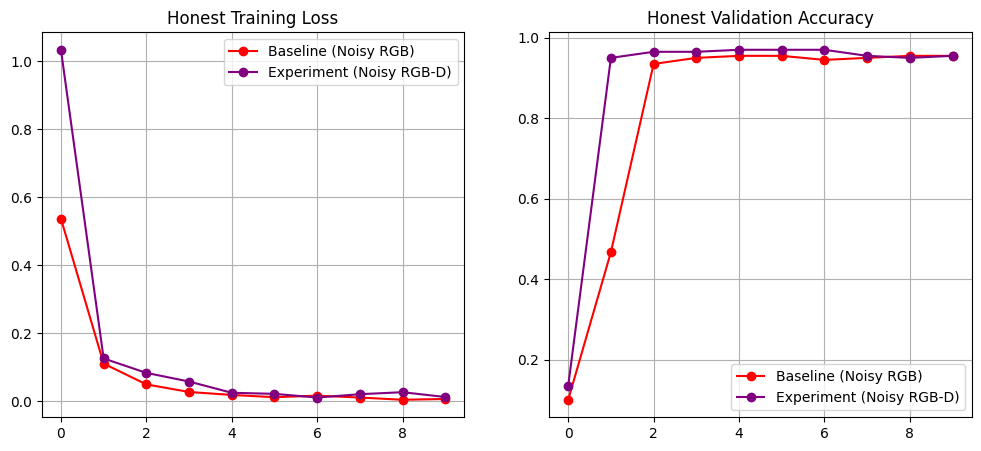

In [20]:
# --- ПЕРЕСБОРКА ДАТАСЕТА ---
def process_and_save_noisy(data_list, save_dir):
    for i, (img, label) in enumerate(tqdm(data_list, desc=f"Честный препроцессинг {save_dir}")):
        img_resized = img.resize((224, 224))

        # Генерируем шум сразу
        rgb_tensor = F.to_tensor(img_resized)
        noisy_rgb_tensor = simulate_bad_sensor(rgb_tensor)

        noisy_img_pil = F.to_pil_image(noisy_rgb_tensor)
        img_path = f"/content/temp_noisy_{i}.jpg"
        noisy_img_pil.save(img_path)

        with torch.no_grad():
            pred = model.inference([img_path])

        depth = torch.from_numpy(pred.depth[0]).unsqueeze(0)

        # Записываем зашумленный RGB и честную глубину
        torch.save({'rgb': noisy_rgb_tensor, 'depth': depth, 'label': label}, f"{save_dir}/sample_{i}.pt")
        if os.path.exists(img_path):
            os.remove(img_path)

# Удаляем старые читерские тензоры
!rm -rf /content/processed/train/* /content/processed/test/*

print("Генерируем честный стресс-датасет...")
process_and_save_noisy(train_data, '/content/processed/train')
process_and_save_noisy(test_data, '/content/processed/test')

# Перезагружаем DataLoader, чтобы он подхватил новые файлы
train_dataset = RGBDepthDataset('/content/processed/train', is_train=True)
test_dataset = RGBDepthDataset('/content/processed/test', is_train=False)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --- ОБУЧЕНИЕ ---
print("\n=== Честное обучение Baseline (Noisy RGB) ===")
net_base_honest = get_resnet_baseline()
# Используем базовую функцию обучения, так как шум уже в данных
hist_base_honest = train_and_eval(net_base_honest, use_depth=False)

print("\n=== Честное обучение Experiment (Noisy RGB + Honest Depth) ===")
net_exp_honest = get_resnet_experiment()
hist_exp_honest = train_and_eval(net_exp_honest, use_depth=True)

# Графики
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_base_honest['loss'], label='Baseline (Noisy RGB)', marker='o', color='red')
plt.plot(hist_exp_honest['loss'], label='Experiment (Noisy RGB-D)', marker='o', color='purple')
plt.title('Honest Training Loss')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_base_honest['acc'], label='Baseline (Noisy RGB)', marker='o', color='red')
plt.plot(hist_exp_honest['acc'], label='Experiment (Noisy RGB-D)', marker='o', color='purple')
plt.title('Honest Validation Accuracy')
plt.legend(); plt.grid(True)
plt.show()

Вывод:

В рамках эксперимента исследовалось влияние структурной информации (карт глубины, сгенерированных моделью Depth Anything 3) на точность классификации (ResNet-18) в условиях сильной деградации оптического сигнала.

Результаты показали, что когда карты глубины извлекаются непосредственно из зашумленных изображений, а не из идеальных исходников - интеграция (пространственного) канала не дает статистически значимого прироста метрик (точность обеих архитектур составила ~95.5%).

Это объясняется информационным пределом исходных данных: при критическом разрушении высокочастотных визуальных признаков (текстур и границ) генеративная модель теряет способность восстанавливать достоверную геометрию объектов, откатываясь к низкочастотным градиентам.